# Project: Bayesian Analysis of Mushroom Preservation

## 1. Introduction 

This applied Bayesian analysis project aims to model the impact of **storage temperature** on the **spoilage rate** of harvested oyster mushrooms, using an approach based on Bayesian logistic regression.


### Project Goal

The main objective is to estimate the parameters $(\alpha, \beta)$ of the probabilistic model that links the storage temperature $x_i$ to the probability $p_i$ that a mushroom spoils. This relationship is defined by the **logistic (or sigmoid) function**:

$$p_i = \text{sigm}(\alpha + \beta x_i) = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}$$


### Probabilistic Model Structure

The complete model combines a **Binomial Likelihood** with **Gaussian Priors** on the parameters, defining the full probabilistic model:

##### Likelihood

Assuming the outcomes of the $n_i$ mushrooms within each group $i$ are **independent** , the number of spoiled mushrooms $y_i$ out of $n_i$ total at a given temperature $x_i$ is modeled with a **Binomial distribution**:

$$y_i | \alpha, \beta \sim \text{Bin}(n_i, p_i)$$

##### Prior

The model parameters $\theta = [\begin{matrix}\alpha & \beta\end{matrix}]^{\top}$ are assigned a **Gaussian (Normal) prior probability distribution**[cite: 1866]:

* **Intercept Parameter ($\alpha$):**
    $$\alpha \sim \mathcal{N}(\mu_{\alpha}, \sigma_{\alpha}^2)$$
    with $\mu_{\alpha}=0$ and $\sigma_{\alpha}=2$.

* **Slope Parameter ($\beta$):**
    $$\beta \sim \mathcal{N}(\mu_{\beta}, \sigma_{\beta}^2)$$
    with $\mu_{\beta}=0$ and $\sigma_{\beta}=1$.

### Experimental Data

The data used for model calibration comes from an experiment across $N=4$ storage temperature levels, recording the number of spoiled mushrooms after 5 days.

| Level ID | Storage Temperature ($^{\circ}C$) $x_i$ | Total Mushrooms $n_i$ | Spoiled Mushrooms $y_i$ |
| :--------: | :-------------------------------------------: | :-----------------: | :---------------------: |
| 1          | 2                                             | 30                  | 2                       |
| 2          | 8                                             | 25                  | 4                       |
| 3          | 15                                            | 20                  | 5                       |
| 4          | 25                                            | 30                  | 20                      |


## 1.1: Probabilistic model

• Derive and comment the full probabilistic model.

The full probabilistic model for the mushroom spoilage problem is specified by defining the **likelihood function** for the observed data ($y_i$) and the **prior distribution** for the unknown parameters $\theta = [\alpha, \beta]^{\top}$. Finally, we define the full posterior distribution using Bayes' theorem.

### 1. Likelihood Function: $P(y|\theta)$

The likelihood function expresses the probability of observing the spoiled mushrooms $y = (y_1, y_2, y_3, y_4)$ given the parameters $\theta$.

**Individual Spoilage Probability ($p_i$)**

The probability $p_i$ that a single mushroom spoils is assumed to depend on the storage temperature $x_i$ via the **logistic (sigmoid) function**:

$$p_i = \text{sigm}(\alpha + \beta x_i) = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}$$

**Binomial Distribution**

For each storage level $i$, the number of spoiled mushrooms $y_i$ out of $n_i$ total is the result of $n_i$ independent Bernoulli trials with probability $p_i$. Therefore, $y_i$ follows a **Binomial distribution**:

$$y_i | \alpha, \beta \sim \text{Binomial}(n_i, p_i)$$

**Joint Likelihood**

Since the outcomes across the four groups are assumed to be **independent** given $\theta$, the joint likelihood for all observations is the product of the individual Binomial probabilities:

$$\mathcal{L}(\theta) = P(y | \theta) = \prod_{i=1}^{4} P(y_i | \alpha, \beta) = \prod_{i=1}^{4} \left[ \binom{n_i}{y_i} p_i^{y_i} (1-p_i)^{n_i - y_i} \right]$$

### 2. Prior Distribution: $f(\theta)$

The prior density function $f(\theta)$ quantifies our initial knowledge (or uncertainty) about the parameters $\alpha$ and $\beta$.

**Individual Priors**

The parameters are assumed to follow **Gaussian (Normal) distributions**:

* $\alpha \sim \mathcal{N}(\mu_{\alpha}=0, \sigma_{\alpha}^2=2^2)$
* $\beta \sim \mathcal{N}(\mu_{\beta}=0, \sigma_{\beta}^2=1^2)$

**Joint Prior Density**

Assuming $\alpha$ and $\beta$ are independent, the joint prior density $f(\theta)$ is the product of the individual Normal probability density functions (PDFs):

$$f(\theta) = f(\alpha) \cdot f(\beta) = \left( \frac{1}{\sqrt{2\pi \cdot 2^2}} e^{-\frac{(\alpha - 0)^2}{2 \cdot 2^2}} \right) \cdot \left( \frac{1}{\sqrt{2\pi \cdot 1^2}} e^{-\frac{(\beta - 0)^2}{2 \cdot 1^2}} \right)$$

### 3. Full Posterior Distribution: $P(\theta|y) \cdot f(\theta)$

**Step 1: Likelihood from Section 1**

From the Binomial model, we have:

$$P(y|\theta) = \prod_{i=1}^{4} \binom{n_i}{y_i} p_i^{y_i} (1-p_i)^{n_i - y_i}$$

The binomial coefficients $\binom{n_i}{y_i}$ don't depend on $\theta$, so we can drop them in the proportionality:

$$P(y|\theta) \propto \prod_{i=1}^{4} p_i^{y_i} (1-p_i)^{n_i - y_i}$$

and finally we can say that $$P(y|\theta) \propto \mathcal{L}(\theta)$$

**Step 2: Prior from Section 2**

From the Gaussian priors:

$$f(\alpha) \propto \exp\left(-\frac{\alpha^2}{2 \cdot 2^2}\right) = \exp\left(-\frac{\alpha^2}{8}\right)$$

$$f(\beta) \propto \exp\left(-\frac{\beta^2}{2 \cdot 1^2}\right) = \exp\left(-\frac{\beta^2}{2}\right)$$

Since $\alpha$ and $\beta$ are independent:

$$f(\theta) = f(\alpha) \cdot f(\beta) \propto \exp\left(-\frac{\alpha^2}{8} - \frac{\beta^2}{2}\right)$$

By **Bayes' Theorem**, the posterior distribution combines the likelihood and prior:

$$f(\theta|y) = \frac{P(y|\theta) \cdot f(\theta)}{P(y)} \propto \mathcal{L}(\theta) \cdot f(\theta)$$

where $P(y)$ is the **marginal likelihood** (normalizing constant), which does not depend on $\theta$.

**Unnormalized Posterior**

Substituting the expressions derived above:

$$f(\theta|y) \propto \left[ \prod_{i=1}^{4} p_i^{y_i} (1-p_i)^{n_i - y_i} \right] \cdot \exp\left(-\frac{\alpha^2}{8} - \frac{\beta^2}{2}\right)$$

where $p_i = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}$.

**Key Properties:**

1. **Non-conjugacy**: The posterior is **not analytically tractable** due to the logistic transformation—there's no closed-form solution.
2. **Computational Methods Needed**: We must use:
   - Numerical optimization (MAP estimation, section 1.3)
   - Grid approximation (section 1.4)
   - MCMC sampling (Metropolis, section 1.5)
3. **Prior Regularization**: The Gaussian priors penalize extreme values of $\alpha$ and $\beta$, preventing overfitting.

**Model Interpretation:**

1. **Why Logistic Regression?**
   - The logistic function ensures $p_i \in [0, 1]$, making it suitable for probabilities
   - It models a smooth, S-shaped relationship between temperature and spoilage risk
   
2. **Physical Meaning of Parameters:**
   - **α (intercept)**: Baseline log-odds of spoilage at 0°C
   - **β (slope)**: Rate of change in spoilage risk with temperature
     - If $\beta > 0$: higher temperature → higher spoilage (expected for mushrooms)
     - If $\beta < 0$: higher temperature → lower spoilage (biologically unlikely)
   
3. **Why These Priors?**
   - **Weakly informative**: Centered at 0 with moderate variance ($\sigma_{\alpha}=2$, $\sigma_{\beta}=1$)
   - They express uncertainty without imposing strong beliefs
   - Allow the data to dominate the inference while preventing extreme parameter values

In [62]:
import numpy as np
import scipy
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
import pandas as pd
from scipy.optimize import minimize
import numpy as np
import plotly.graph_objects as go
from scipy.optimize import minimize
import scipy.stats as stats
from plotly.subplots import make_subplots

## 1.2 Maximum Likelihood Estimation (MLE)

- Derive an analytical expression of the likelihood function $\mathcal{L}(\theta) = P(y \mid \theta)$.
- Derive an analytical expression of the log-likelihood function $\ell(\theta)$.
- Write a Python function corresponding to the log-likelihood function $\ell(\theta)$ (possibly up to an additive factor).
- Visualize the likelihood $\mathcal{L}(\theta)$ and the log-likelihood function $\ell(\theta)$ in 2D and comment the obtained figures.
Hints:
    - you may use the pcolormesh function of matplotlib
    - you need to find appropriate range and step size for both $\alpha$ and $\beta$
- Compute the maximum likelihood (ML) estimates $\alpha^{ML}$, $\beta^{ML}$ of the parameters $\alpha$, $\beta$
through numerical optimizations.
Hints:
    - You may use the Python function scipy.optimize.minimize.
    -  You may look at the figures above to define a good starting point for optimization
    - You may either minimize the likelihood or the log-likelihood. What is your choice?
- Visualize the likelihood function in 2D together with the ML estimate. Comment the obtained figure.

### Analytical Expressions

**Likelihood Function**

From section 1.1, the likelihood is:

$$\mathcal{L}(\theta) = P(y_{i} | \theta) = \prod_{i=1}^{4} \binom{n_i}{y_i} p_i^{y_i} (1-p_i)^{n_i - y_i}$$

where $p_i = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}$.

**Log-Likelihood Function**

Taking the logarithm:

$$\ell(\theta) = \log \mathcal{L}(\theta) = \sum_{i=1}^{4} \left[ \log \binom{n_i}{y_i} + y_i \log p_i + (n_i - y_i) \log(1 - p_i) \right]$$

Since $\log \binom{n_i}{y_i}$ doesn't depend on $\theta$, we can drop it for optimization:

$$\ell(\theta) = \sum_{i=1}^{4} \left[ y_i \log p_i + (n_i - y_i) \log(1 - p_i) \right] + \text{const}$$

In [63]:
# Data
x = np.array([2, 8, 15, 25])  # temperatures
n = np.array([30, 25, 20, 30])  # total mushrooms
y = np.array([2, 4, 5, 20])  # spoiled mushrooms

In [64]:
# Logistic (sigmoid) function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Log-likelihood function (up to additive constant)
def log_likelihood(theta, x, n, y):
    alpha, beta = theta
    z = alpha + beta * x
    p = sigmoid(z)
    
    # Numerical stability: clip probabilities
    p = np.clip(p, 1e-10, 1 - 1e-10)
    
    # Log-likelihood
    ll = np.sum(y * np.log(p) + (n - y) * np.log(1 - p))
    return ll

# Negative log-likelihood (for minimization)
def neg_log_likelihood(theta, x, n, y):
    return -log_likelihood(theta, x, n, y)

Now we should define a possible range for both parameters $\alpha$ and $\beta$ to visualize the likelihood and log-likelihood functions. A reasonable range should consider that $p_i = \sigma(\alpha + \beta x_i)$ can be transformed into $logit(p_i)= log(\dfrac{p_i}{1 - p_i}) = \alpha + \beta x_i$. If we calculate the logit for the minimum and maximum observed proportions of spoiled mushrooms, we can get a plausible range for $\alpha = [-6, 2]$ and for $\beta = [-0.2, 0.4]$.

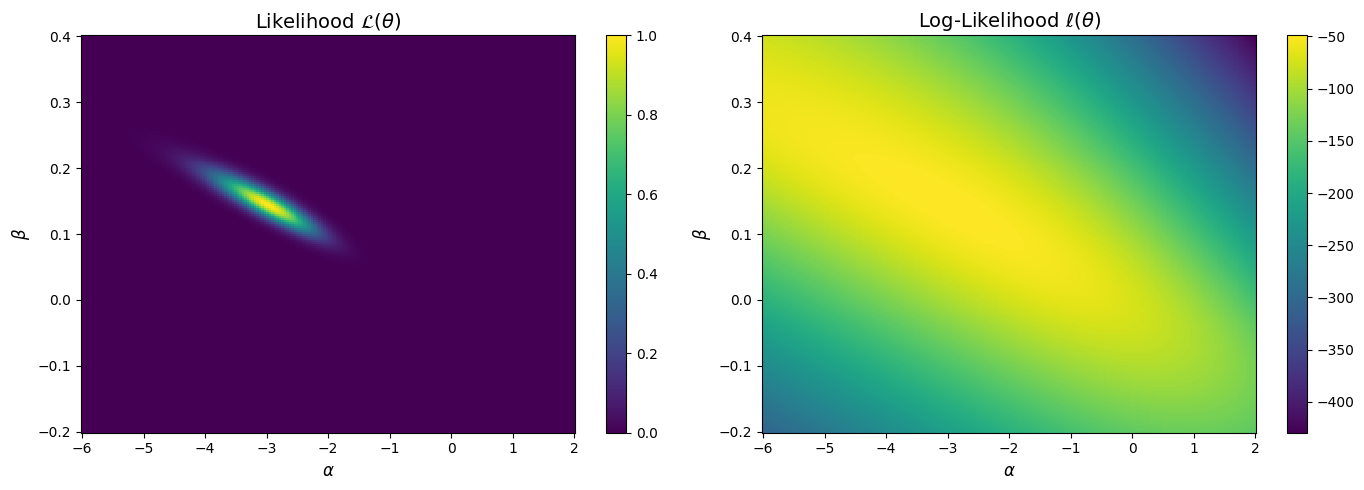

In [65]:
# Create grid for visualization
alpha_range = np.linspace(-6, 2, 200)
beta_range = np.linspace(-0.2, 0.4, 200)
Alpha, Beta = np.meshgrid(alpha_range, beta_range)

# Compute log-likelihood on grid
LL = np.zeros_like(Alpha)
for i in range(Alpha.shape[0]):
    for j in range(Alpha.shape[1]):
        LL[i, j] = log_likelihood([Alpha[i, j], Beta[i, j]], x, n, y)

# Compute likelihood (for visualization)
L = np.exp(LL - np.max(LL))  # Normalize for numerical stability

# Plot likelihood
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Likelihood plot
im1 = axes[0].pcolormesh(Alpha, Beta, L, shading='auto', cmap='viridis')
axes[0].set_xlabel(r'$\alpha$', fontsize=12)
axes[0].set_ylabel(r'$\beta$', fontsize=12)
axes[0].set_title(r'Likelihood $\mathcal{L}(\theta)$', fontsize=14)
plt.colorbar(im1, ax=axes[0])

# Log-likelihood plot
im2 = axes[1].pcolormesh(Alpha, Beta, LL, shading='auto', cmap='viridis')
axes[1].set_xlabel(r'$\alpha$', fontsize=12)
axes[1].set_ylabel(r'$\beta$', fontsize=12)
axes[1].set_title(r'Log-Likelihood $\ell(\theta)$', fontsize=14)
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

In [66]:
from scipy.optimize import minimize

# Initial guess (from visual inspection)
theta_init = np.array([-3.0, 0.15])

# Optimization
result = minimize(
    neg_log_likelihood,
    theta_init,
    args=(x, n, y),
    method='BFGS'
)

# ML estimates
alpha_ML, beta_ML = result.x
print(f"ML Estimates:")
print(f"α_ML = {alpha_ML:.4f}")
print(f"β_ML = {beta_ML:.4f}")
print(f"Log-likelihood at MLE: {-result.fun:.4f}")

ML Estimates:
α_ML = -2.9776
β_ML = 0.1439
Log-likelihood at MLE: -48.9011


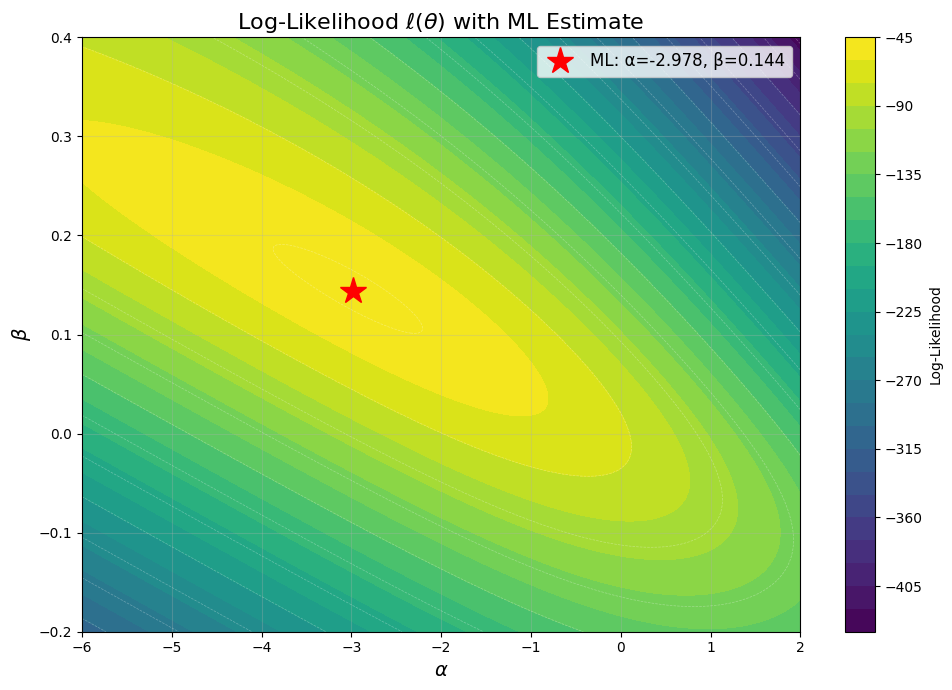

In [67]:
# Plot log-likelihood with ML estimate
fig, ax = plt.subplots(figsize=(10, 7))

# Contour plot
contour = ax.contourf(Alpha, Beta, LL, levels=30, cmap='viridis')
ax.contour(Alpha, Beta, LL, levels=15, colors='white', alpha=0.3, linewidths=0.5)

# ML estimate
ax.plot(alpha_ML, beta_ML, 'r*', markersize=20, label=f'ML: α={alpha_ML:.3f}, β={beta_ML:.3f}')

ax.set_xlabel(r'$\alpha$', fontsize=14)
ax.set_ylabel(r'$\beta$', fontsize=14)
ax.set_title(r'Log-Likelihood $\ell(\theta)$ with ML Estimate', fontsize=16)
ax.legend(fontsize=12)
ax.grid(alpha=0.3)

plt.colorbar(contour, ax=ax, label='Log-Likelihood')
plt.tight_layout()
plt.show()

## 1.3 Maximum a Posteriori (MAP) Estimation

- Derive an analytical expression of the posterior $f(\theta | y)$, up to a multiplicative factor not depending on 𝜃.
Hint: exploit the already-obtained likelihood and the known functional form of the Gaussian pdf.
- Derive an analytical expression of the log-posterior $g(\theta) = f(\theta | y)$, up to an additive factor not depending on $\theta$.
- Write the unnormalized log-posterior (up to a multiplicative/additive factor, respectively) as Python functions.
- Compute the maximum a posteriore estimates $\alpha^{MAP}$, $\beta^{MAP}$
- Visualize the MAP and the ML estimate together with the unnormalized posterior in 2D. Comment the results

### 1.3.1 Analytical expression of the Posterior $f(\theta \mid y)$


The analytical expression for the (unnormalized) posterior probability follows directly from Bayes' theorem:

$$
f(\theta \mid y) \propto \mathcal{L}(\theta) \cdot f(\theta)
$$

Where:

**Likelihood** $\mathcal{L}(\theta) = P(y \mid \theta)$ so we have:

$$
\mathcal{L}(\theta) \propto \prod_{i=1}^{4} p_i^{y_i} (1 - p_i)^{n_i - y_i}
$$

**Prior:** $f(\theta) = f(\alpha) \cdot f(\beta)$ so we have:

$$
f(\theta) \propto \exp\Bigg(-\frac{(\alpha - \mu_{\alpha})^2}{2 \sigma_{\alpha}^2} - \frac{(\beta - \mu_{\beta})^2}{2 \sigma_{\beta}^2}\Bigg)
$$


Substituting the mean and standard deviation values for the priors ($\mu_{\alpha}=0, \sigma_{\alpha}=2, \mu_{\beta}=0, \sigma_{\beta}=1$) we obtain:

$$
f(\theta \mid y) \propto \left[ \prod_{i=1}^{4} p_i^{y_i} (1 - p_i)^{n_i - y_i} \right] \cdot \exp\Big(-\frac{\alpha^2}{8} - \frac{\beta^2}{2}\Big)
$$

where

$$
p_i = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}.
$$


###  1.3.2 Analytical expression of the Log-Posterior $g(\theta)$

$$
g(\theta) = \log f(\theta \mid y) = \log \mathcal{L}(\theta) + \log f(\theta) + \text{const}
$$

Using the previously derived expressions (omitting additive constants that do not depend on $\theta$):

**Log-Likelihood** $\ell(\theta) = \log \mathcal{L}(\theta)$:

$$
\ell(\theta) \propto \sum_{i=1}^{4} \Big[ y_i \log p_i + (n_i - y_i) \log(1 - p_i) \Big]
$$

**Log-Prior** $\log f(\theta)$:

$$
\log f(\theta) \propto -\frac{\alpha^2}{8} - \frac{\beta^2}{2}
$$

The final expression of the log-posterior (up to an additive constant) is:

$$
g(\theta) \propto \sum_{i=1}^{4} \Big[ y_i \log p_i + (n_i - y_i) \log(1 - p_i) \Big] - \frac{\alpha^2}{8} - \frac{\beta^2}{2}
$$

where

$$
p_i = \frac{1}{1 + e^{-(\alpha + \beta x_i)}}.
$$


### 1.3.3 Python Function for un-normalized log-posterior

In [68]:
def log_posterior(theta, x, n, y):
    alpha, beta = theta

    log_prior_alpha = stats.norm.logpdf(alpha, loc=0, scale=2)
    log_prior_beta = stats.norm.logpdf(beta, loc=0, scale=1)
    log_prior = log_prior_alpha + log_prior_beta
    
    # Log-likelihood
    log_lik = log_likelihood(theta, x, n, y)
    
    # Log-posterior 
    log_post = log_prior + log_lik
    return log_post

def neg_log_posterior(theta, x, n, y):
    return -log_posterior(theta, x, n, y)

### 1.3.4 Compute the maximum a posteriore estimates $\alpha^{MAP}$, $\beta^{MAP}$

In [69]:
# Initial guess (from ML estimates)
theta_init_map = np.array([-3.0, 0.2])

# Optimization
result_map = minimize(neg_log_posterior,theta_init_map,args=(x, n, y),method='BFGS')

# MAP estimates
alpha_MAP, beta_MAP = result_map.x
print(f"MAP Estimates:")
print(f"α_MAP = {alpha_MAP:.4f}")
print(f"β_MAP = {beta_MAP:.4f}")

MAP Estimates:
α_MAP = -2.7707
β_MAP = 0.1338


### 1.3.5. Visualize the MAP and the ML estimate together with the unnormalized posterior in 2D. Comment the results

In [70]:
def log_prior(A,B,mu_alpha,sigma_alpha,mu_beta,sigma_beta):
    return -0.5 * (((A - mu_alpha) / sigma_alpha) ** 2 + ((B - mu_beta) / sigma_beta) ** 2)

In [71]:
log_prior = log_prior(Alpha, Beta, 0, 2, 0, 1)
# Compute log-posterior on grid
log_post = LL
post = np.exp(log_post - np.max(log_post))

In [72]:
alpha_vec = np.linspace(alpha_MAP - 1.3, alpha_MAP + 1.3, 100)
beta_vec = np.linspace(beta_MAP - 0.1, beta_MAP + 0.1, 100)
Alpha_grid, Beta_grid = np.meshgrid(alpha_vec, beta_vec)

z_posterior = np.zeros_like(Alpha_grid)
for i in range(Alpha_grid.shape[0]):
    for j in range(Alpha_grid.shape[1]):
        z_posterior[i, j] = log_posterior([Alpha_grid[i, j], Beta_grid[i, j]], x, n, y)
        
UP_norm = np.exp(z_posterior - np.max(z_posterior))

In [73]:
fig = go.Figure()

fig.add_trace(go.Contour(z=UP_norm, x=alpha_vec, y=beta_vec,colorscale='Viridis',name='Posterior Density'))

# ML Values
fig.add_trace(go.Scatter(x=[alpha_ML], y=[beta_ML], mode='markers', marker=dict(color='red', size=12, symbol='x'), name='ML Estimate', showlegend=False))
# MAP Values
fig.add_trace(go.Scatter(x=[alpha_MAP], y=[beta_MAP], mode='markers', marker=dict(color='blue', size=12, symbol='circle'), name='MAP Estimate', showlegend=False))

fig.update_layout(title = "Unnormalized Posterior Density with ML and MAP Estimates",xaxis_title='Alpha',yaxis_title='Beta',width= 900, height=700)
fig.show()

## 1.4 Brute-force posterior estimation

- Compute a gridding approximation of the normalized posterior.
    - Use logarithm transformations for better numerical stability.
- Compute the marginal posterior distributions of $\alpha$ and $\beta$ from the gridding approximation.
- Using the grid-based approximation of the posterior, compute the posterior mean of $\alpha$ and $\beta$.

In [74]:
c = np.sum(UP_norm)
normalized_posterior = UP_norm / c

In [75]:
print(f"Constant of normalizzazion c: {c:.4e}")
print(f"Verify sum = 1: {np.sum(normalized_posterior):.10f}")

Constant of normalizzazion c: 8.1597e+02
Verify sum = 1: 1.0000000000


In [76]:
marginal_alpha = np.sum(normalized_posterior, axis=0)
marginal_beta = np.sum(normalized_posterior, axis=1)

# print(f"Marginal posterior for alpha: {marginal_alpha}")
# print(f"Marginal posterior for beta: {marginal_beta}")

In [77]:
fig = make_subplots(rows=2, cols=1, subplot_titles=('Marginal di α', 'Marginal di β '))
fig.add_trace(go.Scatter(x=alpha_range, y=marginal_alpha, name='P(α|y)', line=dict(color='blue')),row=1, col=1)
fig.add_trace(go.Scatter(x=beta_range, y=marginal_beta, name='P(β|y)', line=dict(color='blue')),row=2, col=1)
fig.show()

## 1.5 Metropolis

- Obtain a sample-based approximation of the posterior $f(\theta| y)$ by implementing the Metropolis algorithm from scratch.
    - Use logarithm transformation for better numerical robustness.
    - Remove the first 1000 samples (they depend on the initial conditions; this is the burn-in period)
    - Run multiple chains and compare visually the posterior distribution provided by the different chains. Do they overlap well?
    - Inspect the trace. Does it show a strong correlation? Which is the rate of acceptance (aim at 50%)?
    - Ajust the algorithm settings if needed, and show how the sampling performs before and after the adjustment.
- Compare the Metropolis samples with the gridding-based approximation of the posterior
distribution $f(\theta| y)$ and comment the result.


As we saw, to obtain the posterior distribution $ f_{post}(\theta) = f(\theta | y) = K f_{prior}(\theta) \mathcal{L}(\theta)$. This means that we can evaluate the posterior up to a normalizing constant $K$. This is sufficient for implementing the Metropolis algorithm, which only requires the ability to compute the unnormalized posterior density at any point $\theta$.

The Metropolis algorithm only needs to compute **ratios** of posterior densities:

$$ ratio = \frac{f(\theta^* | y)}{f(\theta^{(t-1)} | y)} = \frac{K \cdot f(\theta^*) \cdot \mathcal{L}(\theta^*)}{K \cdot f(\theta^{(t-1)}) \cdot \mathcal{L}(\theta^{(t-1)})} = \frac{f(\theta^*) \cdot \mathcal{L}(\theta^*)}{f(\theta^{(t-1)}) \cdot \mathcal{L}(\theta^{(t-1)})}$$

the constant $K$ (where $K = \frac{1}{P(y)}$) cancels out. Therefore, we only need to compute:

$$f(\theta|y) \propto \mathcal{L}(\theta) \cdot f(\theta)$$

which we already derived in sections 1.1 and 1.3.




### Metropolis Algorithm Steps

For our mushroom spoilage problem with $\theta = [\alpha, \beta]^{\top}$:

**1. Initialization:**
- Choose starting values $\theta^{(0)} = [\alpha^{(0)}, \beta^{(0)}]^{\top}$
- Set proposal distribution: $q(\theta^* | \theta^{(t)}) = \mathcal{N}(\theta^{(t)}, \Sigma)$
  where $\Sigma = \begin{bmatrix} \sigma_\alpha^2 & 0 \\ 0 & \sigma_\beta^2 \end{bmatrix}$ is the proposal covariance matrix

**2. Iteration** (for $t = 1, 2, \ldots, N$):

**Step a) Propose new state:**
$$\theta^* \sim \mathcal{N}(\theta^{(t-1)}, \Sigma)$$

**Step b) Compute acceptance ratio:**
$$r = \frac{f(\theta^* | y)}{f(\theta^{(t-1)} | y)} = \frac{\mathcal{L}(\theta^*) \cdot f(\theta^*)}{\mathcal{L}(\theta^{(t-1)}) \cdot f(\theta^{(t-1)})}$$

In **log-space** (for numerical stability):
$$\log r = \log f(\theta^* | y) - \log f(\theta^{(t-1)} | y)$$

we found that:
$$\log r = [\log \mathcal{L}(\theta^*) + \log f(\theta^*)] - [\log \mathcal{L}(\theta^{(t-1)}) + \log f(\theta^{(t-1)})]$$

and expanding the terms:
$$\log r = \underbrace{\left[\sum_{i=1}^{4} y_i \log p_i^* + (n_i - y_i) \log(1-p_i^*)\right]}_{\text{Log-likelihood at } \theta^*} \underbrace{- \frac{(\alpha^*)^2}{8} - \frac{(\beta^*)^2}{2}}_{\text{Log-prior at } \theta^*}$$
$$- \underbrace{\left[\sum_{i=1}^{4} y_i \log p_i^{(t-1)} + (n_i - y_i) \log(1-p_i^{(t-1)})\right]}_{\text{Log-likelihood at } \theta^{(t-1)}} \underbrace{+ \frac{(\alpha^{(t-1)})^2}{8} + \frac{(\beta^{(t-1)})^2}{2}}_{\text{Log-prior at } \theta^{(t-1)}}$$

where $p_i^* = \frac{1}{1 + e^{-(\alpha^* + \beta^* x_i)}}$ and $p_i^{(t-1)} = \frac{1}{1 + e^{-(\alpha^{(t-1)} + \beta^{(t-1)} x_i)}}$.

**Step c) Accept/Reject:**
- Compute acceptance probability: $\alpha = \min(1, r)$
- Generate $u \sim \text{Uniform}(0, 1)$
- If $u < \alpha$: accept $\theta^{(t)} = \theta^*$
- Else: reject $\theta^{(t)} = \theta^{(t-1)}$

**3. Output:**
After burn-in period (first $B$ samples), the remaining samples $\{\theta^{(B+1)}, \ldots, \theta^{(N)}\}$ approximate the posterior distribution.
